In [1]:
import pandas as pd
import math
import numpy as np
import yfinance as yf
from sklearn.preprocessing import StandardScaler
df = yf.download('^BSESN', 
                        start='2010-01-01', 
                        end='2021-06-12', 
                        progress=True,
    )
#print(df.head())
df['Daily_return'] = np.log(df['Close'] / df['Close'].shift(1))
df['3_D']=df['Close'] - df['Close'].shift(3)
df['5_D']=df['Close'] - df['Close'].shift(5)
df['5D_Mean'] = df['Close'].rolling(window=5).mean()
df['Momentum'] = df['Close'] - df['Close'].shift(3)
df['3D_log_return'] = np.log(df['Close'].shift(-3) / df['Close'])
col = [c[0] for c in df.columns.to_flat_index()]
df.dropna(inplace=True)
import matplotlib.pyplot as plt
#plt.plot(df['3D_log_return'],df['Open'],label='Open')
print(col)

C:\Users\umava\AppData\Local\Temp\ipykernel_18476\3597909868.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('^BSESN',
[*********************100%***********************]  1 of 1 completed


['Close', 'High', 'Low', 'Open', 'Volume', 'Daily_return', '3_D', '5_D', '5D_Mean', 'Momentum', '3D_log_return']


In [2]:
from sklearn.preprocessing import StandardScaler
import numpy as np
scaled_data=StandardScaler()
# Step 1: Choose window size and features
window_size = 60
target_column = '3D_log_return'

# Step 2: Scale the feature columns
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df[['3D_log_return']].values)
# Step 3: Create sequences
X = []
y = []

for i in range(window_size, len(scaled_data)):
    X.append(scaled_data[i-window_size:i])  # 60 timesteps
    y.append(scaled_data[i])       # predict next value

X = np.array(X)
y = np.array(y)

# Step 4: Train/Test split (chronological)
split_index = int(len(X) * 0.8)
X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print("Sample X_train[0]:", X_train[0])
print("Sample y_train[0]:", y_train[0])


X_train shape: (2192, 60, 1)
y_train shape: (2192, 1)
Sample X_train[0]: [[ 0.11068269]
 [ 0.32904663]
 [ 0.32561154]
 [-0.35196117]
 [-0.29622515]
 [-1.81929622]
 [-1.94679787]
 [-2.15609779]
 [-2.42237188]
 [-1.78440899]
 [-1.37914116]
 [ 0.14912584]
 [-0.51740875]
 [ 0.37405344]
 [-0.47665866]
 [-1.2661985 ]
 [-1.8478162 ]
 [-0.64637092]
 [ 0.36735176]
 [ 0.63867334]
 [-0.07295393]
 [ 0.91892867]
 [ 0.81644147]
 [ 0.86435819]
 [-0.17241413]
 [-0.66799608]
 [-0.1922568 ]
 [ 0.1444471 ]
 [-0.00602184]
 [ 0.39213508]
 [ 1.55696804]
 [ 2.25906073]
 [ 1.61806259]
 [ 0.61906579]
 [ 0.25048509]
 [ 0.18509492]
 [ 0.25436602]
 [ 0.13662192]
 [ 0.28414999]
 [ 0.14058369]
 [ 0.58355436]
 [ 0.90459614]
 [ 0.99569498]
 [ 0.51633818]
 [-0.29619901]
 [-0.26240414]
 [-0.11764756]
 [ 0.63025467]
 [ 0.70503466]
 [ 0.03154015]
 [-0.40457665]
 [-0.11531783]
 [ 0.94516845]
 [ 1.14531909]
 [ 0.74379617]
 [-0.70249315]
 [-0.0843272 ]
 [-0.39841523]
 [ 0.25239872]
 [-0.91496534]]
Sample y_train[0]: [-0.824

In [ ]:
import torch
import torch.nn as nn

class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size=50, num_layers=1):
        super(LSTMModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        self.lstm = nn.LSTM(
            input_size=input_size,       # equivalent to X_train.shape[2]
            hidden_size=hidden_size,     # equivalent to units=50
            num_layers=num_layers,
            batch_first=True
        )
        
        self.fc = nn.Linear(hidden_size, 1)  # equivalent to Dense(1)

    def forward(self, x):
        # x shape: (batch_size, sequence_length, input_size)
        out, _ = self.lstm(x)                # out shape: (batch_size, sequence_length, hidden_size)
        out = out[:, -1, :]                  # take last time step: shape (batch_size, hidden_size)
        out = self.fc(out)                   # shape: (batch_size, 1)
        return out
class StackedLSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers):
        super(StackedLSTMModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
            dropout=0.2
        )
        self.fc = nn.Linear(hidden_size, 1)
        nn.dropout(0.2)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = self.fc(out)
        return out



In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# Convert numpy arrays to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)

# Wrap tensors in a Dataset and DataLoader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# Instantiate model
model = LSTMModel(input_size=X_train.shape[2], hidden_size=50, num_layers=2)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Training loop
num_epochs = 20
for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        output = model(X_batch)  # shape: (batch,)
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss/len(train_loader):.6f}")


Epoch 1/20, Loss: 0.716985
Epoch 2/20, Loss: 0.489029
Epoch 3/20, Loss: 0.355507
Epoch 4/20, Loss: 0.288748
Epoch 5/20, Loss: 0.281451
Epoch 6/20, Loss: 0.272842
Epoch 7/20, Loss: 0.274403
Epoch 8/20, Loss: 0.270881
Epoch 9/20, Loss: 0.269364
Epoch 10/20, Loss: 0.267351
Epoch 11/20, Loss: 0.265101
Epoch 12/20, Loss: 0.268151
Epoch 13/20, Loss: 0.263234
Epoch 14/20, Loss: 0.266674
Epoch 15/20, Loss: 0.261002
Epoch 16/20, Loss: 0.266094
Epoch 17/20, Loss: 0.262048
Epoch 18/20, Loss: 0.264382
Epoch 19/20, Loss: 0.262171
Epoch 20/20, Loss: 0.259090


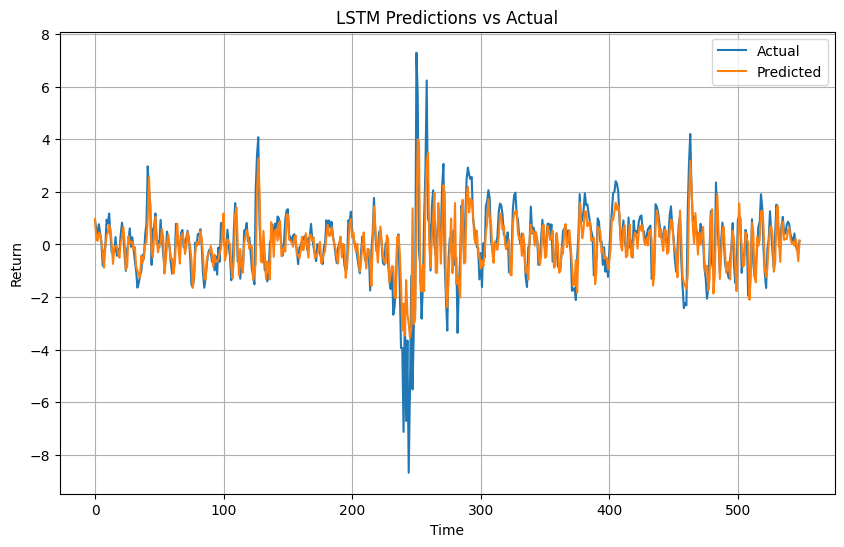

MSE: 0.814019, RMSE: 0.902230, MAE: 0.559841


In [5]:
# Step 7: Evaluation Mode
model.eval()

# Step 8: Prepare Test Tensors
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

# Step 9: Predict
with torch.no_grad():
    y_pred = model(X_test_tensor).squeeze()

# Step 10: Inverse transform (optional: only if you scaled targets)
# Assuming you scaled only X and not y, you can skip inverse_transform
# Otherwise, you'll need a scaler_y used earlier: y_pred = scaler_y.inverse_transform(y_pred.numpy().reshape(-1,1))

# Step 11: Plot
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(y_test_tensor.numpy(), label='Actual')
plt.plot(y_pred.numpy(), label='Predicted')
plt.xlabel('Time')
plt.ylabel('Return')
plt.title('LSTM Predictions vs Actual')
plt.legend()
plt.grid(True)
plt.show()

# Step 12: Compute Evaluation Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

mse = mean_squared_error(y_test_tensor.numpy(), y_pred.numpy())
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_tensor.numpy(), y_pred.numpy())

print(f'MSE: {mse:.6f}, RMSE: {rmse:.6f}, MAE: {mae:.6f}')
